# Scattering con α libero sui dati simulati con α = 4.4

Stessi dati del notebook 07 (`sim_data_noise_sv44/`: scattering generato con α = 4.4, senza GWB, valori veri standard, seed `key(1)`).

Qui l'indice cromatico dello scattering è un **parametro libero** (`sv_gp_alpha`, prior uniforme in [0, 10] da `my_priordict`), tramite `ds.dmfourierbasis_alpha`, che costruisce la base come (1400/ν)^α. Il modello ha quindi **7 parametri**.

Domande:
1. α viene recuperato vicino a 4.4?
2. Il bias su `sv_gp_log10_A` visto nel notebook 07 (+0.44 dex con α fisso a 4.0) sparisce?
3. Quanto sono degeneri α e `sv_gp_log10_A`? (atteso: molto, perché i dati sono quasi tutti in banda LOFAR)

## Setup comune

Copia delle celle 0, 1, 3, 4, 6, 7, 9 di `Likelihood.ipynb`. `logL.params` (6 parametri) serve come riferimento per l'ordine delle colonne delle catene a 6 parametri.

In [2]:
import numpy as np
import os, glob, json
import pickle

import sys

# this is the path to the discovery folder
sys.path.insert(0, "./")
import discovery_new as ds

import matplotlib.pyplot as plt
import scipy
import jax.numpy as jnp

from scipy.stats import uniform
import re
from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc
from scipy.stats import uniform
import jax

import time
import emcee

Optional mpi4py package is not installed.  MPI support is not available.


In [3]:
# path to the folder with the data
path = './dati/DR2low_feathers/'
s_dsfiles = np.sort(os.listdir(path))
psr = [ds.pulsar.Pulsar.read_feather(path + f'{psrfile}') for psrfile in s_dsfiles][9] # we are only analysing pulsar #9

In [4]:
# data
model = [psr.residuals]
# timing model
model += [ds.makegp_timing(psr, svd=True)]
# white noise parameters
model += [ds.makenoise_measurement(psr, psr.noisedict, tnequad = True, ecorr=True)]
# red noise paramters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_red_components'], T=ds.getspan(psr), name='red_noise' ))
# DM variation parameters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_dm_components'], T=ds.getspan(psr), name='dm_gp', fourierbasis=ds.make_dmfourierbasis(alpha = 2.0, tndm = False)))
# scattering noise parameters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_chrom_components'], T=ds.getspan(psr), name='sv_gp', fourierbasis=ds.make_dmfourierbasis(alpha = 4.0, tndm = False)))

In [5]:
logL = ds.PulsarLikelihood(model).logL

In [6]:
# annoying function needed because the function logL want a dictionary as input, but our sampler wants a likelihood with an array as input
# so we have to switch from one to another :(
def params_dict_from_array(x):
    # ensure x is a plain numpy array before slicing
    x = np.asarray(x)
    return dict(zip(logL.params, x))

In [7]:
##### Cell for the prior distributions ###################################################################################

# dictionary with minimum and maximum value of the prior distribution
my_priordict = {}
my_priordict["(.*_)?sv_gp_gamma.*"] = [0, 7]
my_priordict["(.*_)?sv_gp_alpha.*"] = [0, 10]
my_priordict["(.*_)?sv_gp_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?sw_log10_A.*"] = [-10, 1]
my_priordict["(.*_)?sw_gamma.*"] = [-5, 6]
my_priordict["(.*_)?dm_gp_gamma.*"] = [0, 7]
my_priordict["(.*_)?dm_gp_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?red_noise_gamma.*"] = [0, 7]
my_priordict["(.*_)?red_noise_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?sw_n_earth.*"] = [0, 30]


def build_priors(param_names, priordict):
    """
    Build a {param_name: scipy dist} dict with uniform prior distributions in the range
    """
    priors = {}
    unmatched = []
    for name in param_names:
        matched = False
        for pattern, (lo, hi) in priordict.items():
            if re.fullmatch(pattern, name):
                priors[name] = uniform(loc=lo, scale=hi - lo) ## this is where the uniform distribution is defined
                matched = True
                break
        if not matched:
            unmatched.append(name)

    if unmatched:
        print(f"Warning: no prior found for {len(unmatched)} parameters, "
              f"falling back to standard normal:\n  {unmatched}")
    return priors

priors = build_priors(logL.params, my_priordict)
priors

def log_prior(x):
    """Compute log prior"""
    params = params_dict_from_array(x)
    
    logp = 0.0
    for name, value in params.items():
        if name in priors:
            logp += priors[name].logpdf(value)
        else:
            # Default: standard normal prior
            if isinstance(value, np.ndarray):
                logp += -0.5 * np.sum(value**2)
            else:
                logp += -0.5 * value**2
    
    return logp

def prior_draw():
    """Draw from prior and return as flat array"""
    x = []
    for name in logL.params:
        x.append(priors[name].rvs())
    return np.array(x)

x0 = prior_draw()
x0

array([  5.40867566, -12.32773856,   5.34602315, -18.83067881,
         5.39997128, -12.851843  ])

In [8]:
@jax.jit # compile the likelihood in jax to make it faster
def _jit_logL(params_array):
    params = dict(zip(logL.params, params_array))
    return logL(params)

_jit_logL(x0)

def log_likelihood(x): 
    """
    Likelihood function that is given to the samples, it uses the jitted (=faster) version of the likelihood
    """
    x = np.asarray(x, dtype=np.float64)
    result = _jit_logL(jnp.array(x))
    return float(np.array(result))  # always a plain Python float

## Catena di confronto (letta da disco, nessun sampling)

- `chain_sim_sv44`: stessi dati, analizzati con α **fisso** a 4.0 (notebook 07)

In [9]:
chain_sim_sv44 = np.loadtxt('./test_sim_sv44/chain_1.txt')[:, :-4]
chain_sim_sv44 = chain_sim_sv44[len(chain_sim_sv44)//4:]   # rimuovo il 25% di burn-in
chain_sim_sv44.shape   # atteso (~75000, 6), colonne nell'ordine di logL.params

(75001, 6)

## Dati simulati con scattering α = 4.4

In [10]:
sim_sv44_psr = ds.pulsar.Pulsar.read_feather('sim_data_noise_sv44/J1640+2224')
print('nome     :', sim_sv44_psr.name)
print('N_TOA    :', len(sim_sv44_psr.toas))

nome     : J1640+2224
N_TOA    : 6777


## Modello con α libero

In [11]:
# stesso modello a 6 par, ma lo scattering usa dmfourierbasis_alpha: alpha diventa un parametro libero
model_sim_sv44_af = [sim_sv44_psr.residuals]
model_sim_sv44_af += [ds.makegp_timing(sim_sv44_psr, svd=True)]
model_sim_sv44_af += [ds.makenoise_measurement(sim_sv44_psr, sim_sv44_psr.noisedict, tnequad=True, ecorr=True)]
model_sim_sv44_af.append(ds.makegp_fourier(sim_sv44_psr, ds.powerlaw, sim_sv44_psr.noisedict[sim_sv44_psr.name + '_red_components'],
                                           T=ds.getspan(sim_sv44_psr), name='red_noise'))
model_sim_sv44_af.append(ds.makegp_fourier(sim_sv44_psr, ds.powerlaw, sim_sv44_psr.noisedict[sim_sv44_psr.name + '_dm_components'],
                                           T=ds.getspan(sim_sv44_psr), name='dm_gp',
                                           fourierbasis=ds.make_dmfourierbasis(alpha=2.0, tndm=False)))
model_sim_sv44_af.append(ds.makegp_fourier(sim_sv44_psr, ds.powerlaw, sim_sv44_psr.noisedict[sim_sv44_psr.name + '_chrom_components'],
                                           T=ds.getspan(sim_sv44_psr), name='sv_gp',
                                           fourierbasis=ds.dmfourierbasis_alpha))   # <-- alpha libero

logL_sim_sv44_af = ds.PulsarLikelihood(model_sim_sv44_af).logL
logL_sim_sv44_af.params   # attesi 7 parametri, compreso J1640+2224_sv_gp_alpha

['J1640+2224_sv_gp_alpha',
 'J1640+2224_dm_gp_gamma',
 'J1640+2224_dm_gp_log10_A',
 'J1640+2224_red_noise_gamma',
 'J1640+2224_red_noise_log10_A',
 'J1640+2224_sv_gp_gamma',
 'J1640+2224_sv_gp_log10_A']

In [12]:
# controllo: i 6 parametri standard + sv_gp_alpha
atteso = set(logL.params) | {'J1640+2224_sv_gp_alpha'}
assert set(logL_sim_sv44_af.params) == atteso, \
    f"Mancanti: {atteso - set(logL_sim_sv44_af.params)}\nIn eccesso: {set(logL_sim_sv44_af.params) - atteso}"
print('OK: 7 parametri attesi')
print('ATTENZIONE: ordine diverso da logL.params ->', logL_sim_sv44_af.params)

OK: 7 parametri attesi
ATTENZIONE: ordine diverso da logL.params -> ['J1640+2224_sv_gp_alpha', 'J1640+2224_dm_gp_gamma', 'J1640+2224_dm_gp_log10_A', 'J1640+2224_red_noise_gamma', 'J1640+2224_red_noise_log10_A', 'J1640+2224_sv_gp_gamma', 'J1640+2224_sv_gp_log10_A']


In [13]:
def params_dict_from_array_sim_sv44_af(x):
    x = np.asarray(x)
    return dict(zip(logL_sim_sv44_af.params, x))

priors_sim_sv44_af = build_priors(logL_sim_sv44_af.params, my_priordict)   # sv_gp_alpha: uniforme [0, 10]
print('prior su alpha:', priors_sim_sv44_af['J1640+2224_sv_gp_alpha'].support())

def log_prior_sim_sv44_af(x):
    params = params_dict_from_array_sim_sv44_af(x)
    logp = 0.0
    for name, value in params.items():
        if name in priors_sim_sv44_af:
            logp += priors_sim_sv44_af[name].logpdf(value)
        else:
            logp += -0.5 * np.sum(np.asarray(value)**2)
    return logp

def prior_draw_sim_sv44_af():
    return np.array([priors_sim_sv44_af[name].rvs() for name in logL_sim_sv44_af.params])

x0_sim_sv44_af = prior_draw_sim_sv44_af()
print('x0 =', x0_sim_sv44_af)

prior su alpha: (np.float64(0.0), np.float64(10.0))
x0 = [  0.90922863   4.05152435 -11.08185408   4.51358888 -19.26164738
   6.82548523 -15.10195741]


In [14]:
@jax.jit
def _jit_logL_sim_sv44_af(params_array):
    return logL_sim_sv44_af(dict(zip(logL_sim_sv44_af.params, params_array)))

def log_likelihood_sim_sv44_af(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.array(_jit_logL_sim_sv44_af(jnp.array(x))))

print('logL iniziale =', log_likelihood_sim_sv44_af(x0_sim_sv44_af))

# tempo di una valutazione (dopo la compilazione): serve a stimare la durata del sampling
start = time.time()
for _ in range(20):
    log_likelihood_sim_sv44_af(x0_sim_sv44_af)
dt = (time.time() - start) / 20
print(f'una valutazione = {dt*1e3:.1f} ms  ->  10^6 iterazioni ~ {dt*1e6/3600:.1f} ore (solo likelihood)')

logL iniziale = 67588.03973302673
una valutazione = 65.0 ms  ->  10^6 iterazioni ~ 18.1 ore (solo likelihood)


In [15]:
sampler_sim_sv44_af = ptmcmc(
    ndim=len(logL_sim_sv44_af.params),
    logl=log_likelihood_sim_sv44_af,
    logp=log_prior_sim_sv44_af,
    cov=np.eye(len(logL_sim_sv44_af.params)) * 0.001,
    outDir='./test_sim_sv44_alphafree/',
    resume=True
)

### Sampling (lungo)

Eseguire **una sola volta**. Quando la catena è completa, per rifare i grafici saltare questa cella e ripartire da quella che legge `chain_1.txt`.

In [16]:
print("Starting sampling (sim con scattering alpha=4.4, analizzata con alpha LIBERO)...")
sampler_sim_sv44_af.sample(x0_sim_sv44_af, Niter=1000000, thin=10)

Starting sampling (sim con scattering alpha=4.4, analizzata con alpha LIBERO)...
Resuming run from chain file ./test_sim_sv44_alphafree//chain_1.txt
Resuming with 11101 samples from file representing 111001 original samples
Adding DE jump with weight 20


KeyboardInterrupt: 

## Catena e grafici

**Attenzione all'ordine delle colonne**: qui segue `logL_sim_sv44_af.params` (7 parametri, `sv_gp_alpha` compreso), non `logL.params`. Per i confronti con le catene a 6 parametri le colonne sono selezionate **per nome**.

In [17]:
chain_sim_sv44_af = np.loadtxt('./test_sim_sv44_alphafree/chain_1.txt')[:, :-4]
chain_sim_sv44_af = chain_sim_sv44_af[len(chain_sim_sv44_af)//4:]   # rimuovo il 25% di burn-in
print(chain_sim_sv44_af.shape)   # atteso (~75000, 7)

# indice di ogni parametro nella catena con alpha libero
idx_af = {name: i for i, name in enumerate(logL_sim_sv44_af.params)}
idx_af

(8326, 7)


{'J1640+2224_sv_gp_alpha': 0,
 'J1640+2224_dm_gp_gamma': 1,
 'J1640+2224_dm_gp_log10_A': 2,
 'J1640+2224_red_noise_gamma': 3,
 'J1640+2224_red_noise_log10_A': 4,
 'J1640+2224_sv_gp_gamma': 5,
 'J1640+2224_sv_gp_log10_A': 6}

In [18]:
import emcee
tau_sim_sv44_af = emcee.autocorr.integrated_time(chain_sim_sv44_af, has_walkers=False, quiet=True)
print('tau =', dict(zip(logL_sim_sv44_af.params, np.round(tau_sim_sv44_af, 1))))
print('Effective length =', int(len(chain_sim_sv44_af) / tau_sim_sv44_af.max()))

tau = {'J1640+2224_sv_gp_alpha': np.float64(16.6), 'J1640+2224_dm_gp_gamma': np.float64(31.7), 'J1640+2224_dm_gp_log10_A': np.float64(27.6), 'J1640+2224_red_noise_gamma': np.float64(12.3), 'J1640+2224_red_noise_log10_A': np.float64(6.5), 'J1640+2224_sv_gp_gamma': np.float64(8.5), 'J1640+2224_sv_gp_log10_A': np.float64(18.3)}
Effective length = 262


In [19]:
# valori veri (alpha = 4.4 per costruzione della simulazione)
truths_dict_af = {
    'J1640+2224_dm_gp_gamma': 6.471070651479037,
    'J1640+2224_dm_gp_log10_A': -15.7227863246785,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 1.3259815720503758,
    'J1640+2224_sv_gp_log10_A': -15.888300265911965,
    'J1640+2224_sv_gp_alpha': 4.4,
}

# riepilogo numerico: mediana [16, 84] per ogni parametro
for name in logL_sim_sv44_af.params:
    q16, q50, q84 = np.percentile(chain_sim_sv44_af[:, idx_af[name]], [16, 50, 84])
    print(f"{name.replace('J1640+2224_', ''):20s} vero {truths_dict_af[name]:8.3f} | {q50:8.3f} [{q16:8.3f}, {q84:8.3f}]")

sv_gp_alpha          vero    4.400 |    4.677 [   4.471,    4.902]
dm_gp_gamma          vero    6.471 |    4.836 [   3.796,    5.963]
dm_gp_log10_A        vero  -15.723 |  -14.872 [ -15.313,  -14.476]
red_noise_gamma      vero    0.132 |    0.199 [   0.056,    0.444]
red_noise_log10_A    vero  -13.213 |  -13.246 [ -13.322,  -13.170]
sv_gp_gamma          vero    1.326 |    1.374 [   1.183,    1.570]
sv_gp_log10_A        vero  -15.888 |  -16.102 [ -16.339,  -15.881]


### Corner a 7 parametri

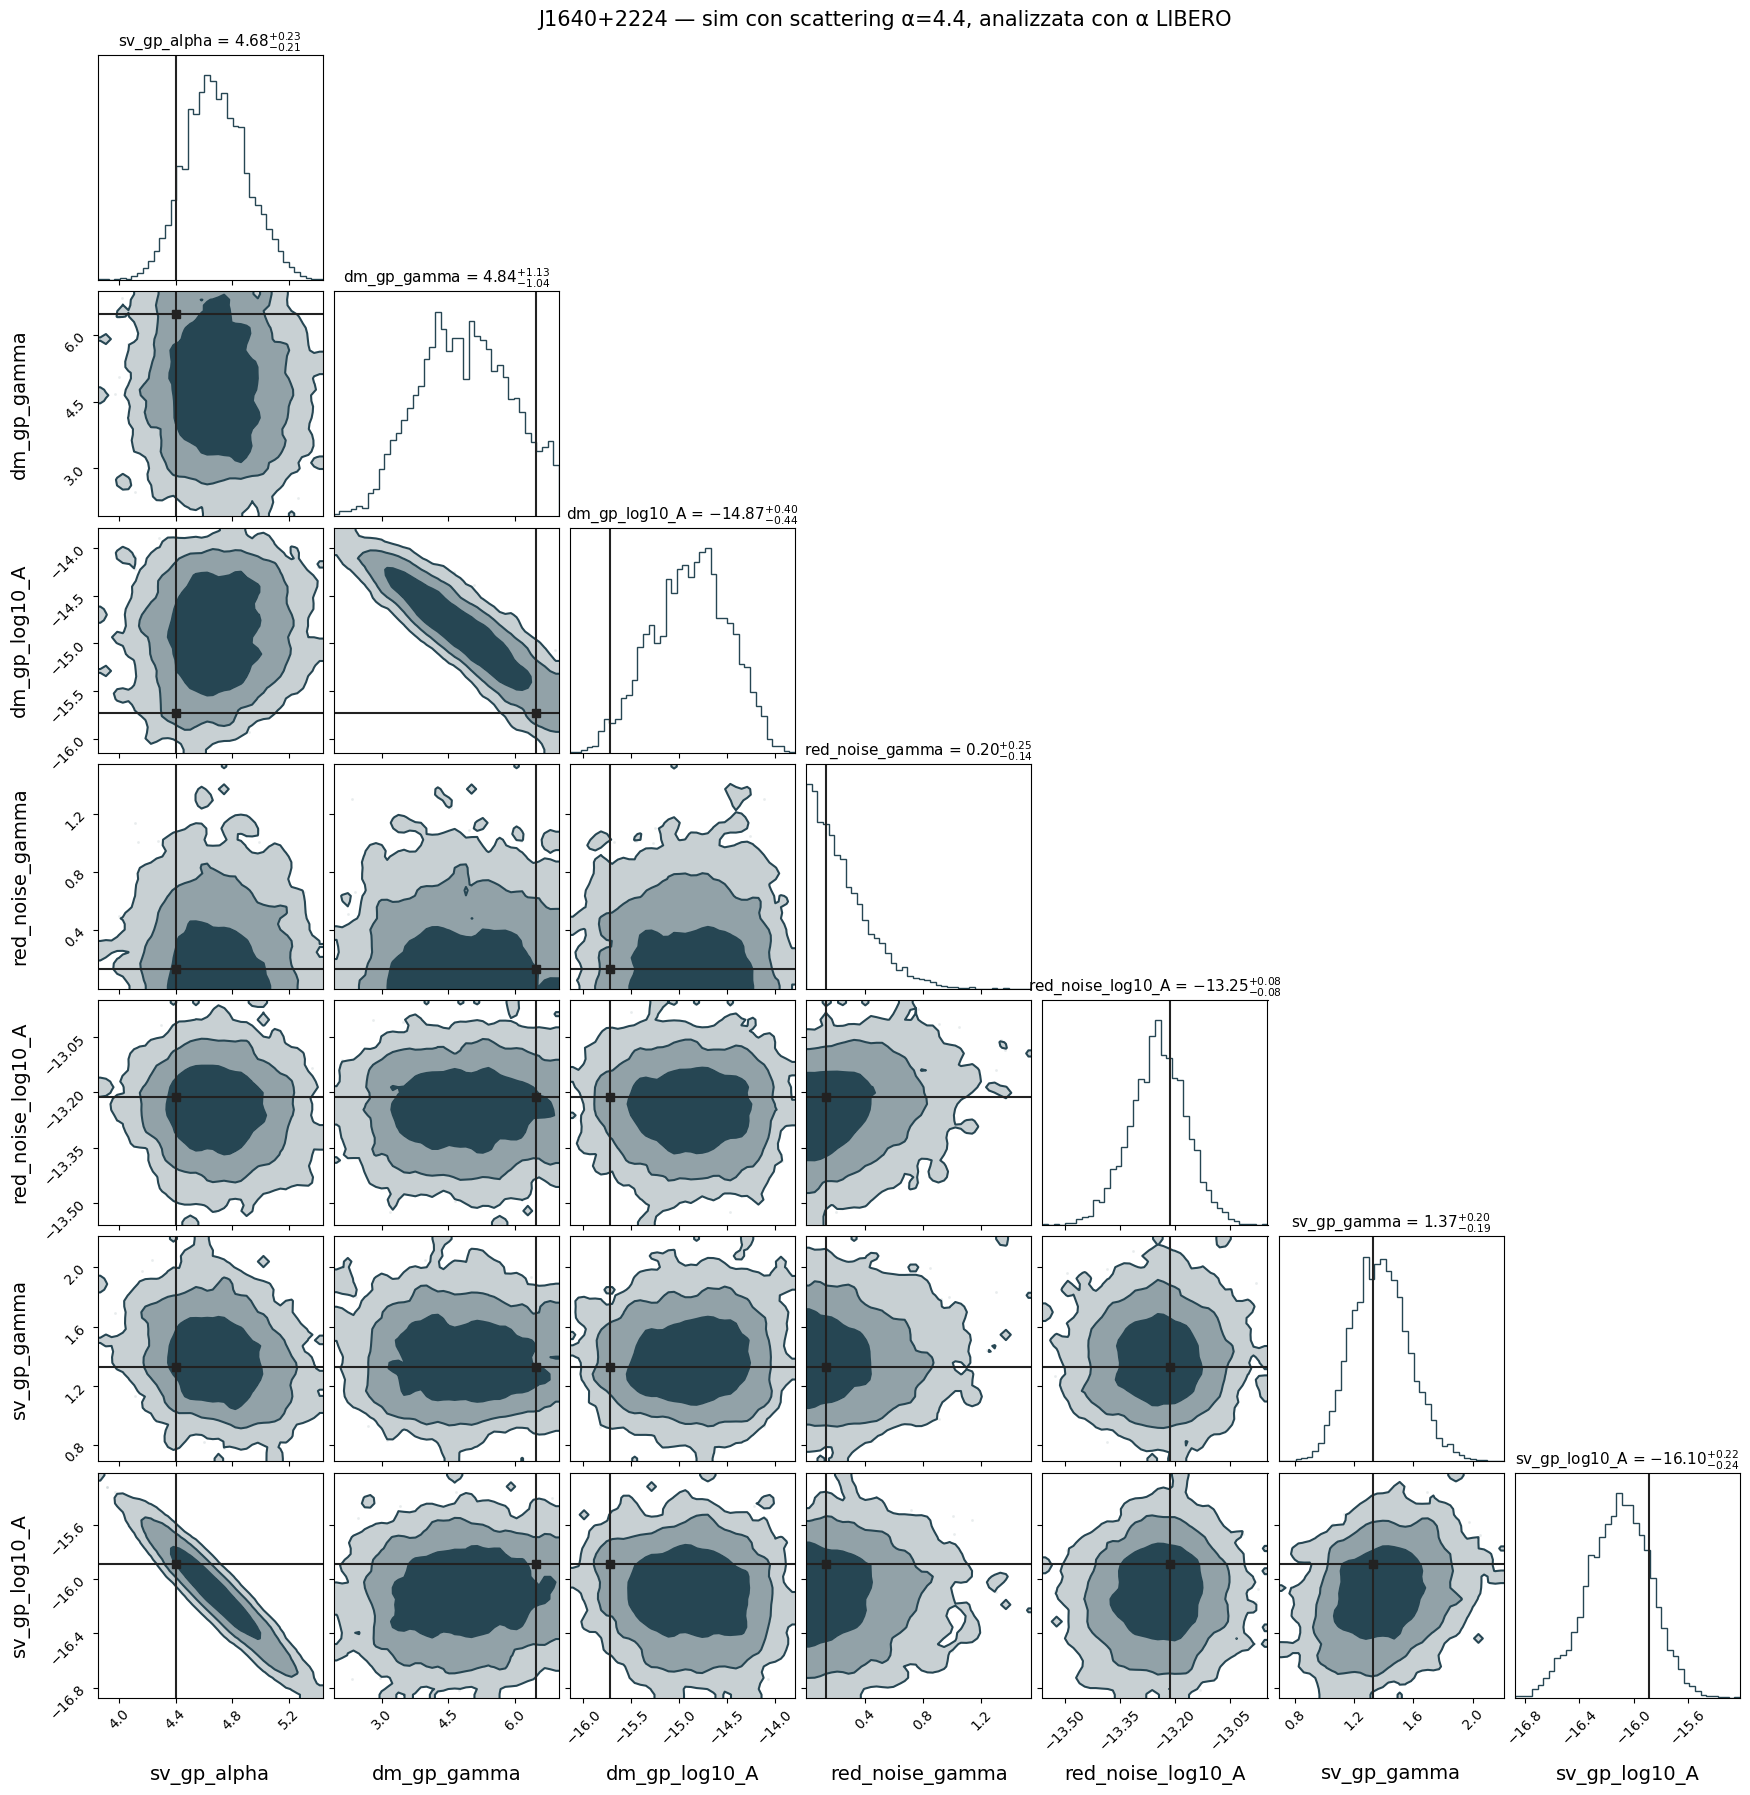

In [20]:
import corner

truth_values_af = [truths_dict_af[p] for p in logL_sim_sv44_af.params]
clean_labels_af = [name.replace('J1640+2224_', '') for name in logL_sim_sv44_af.params]

fig = corner.corner(
    chain_sim_sv44_af,
    labels=clean_labels_af,
    truths=truth_values_af,
    truth_color='#222222',
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.68, 0.95, 0.997),
    smooth=1.0,
    bins=40,
    color='#264653',
)
fig.set_size_inches(18, 18)
fig.suptitle('J1640+2224 — sim con scattering α=4.4, analizzata con α LIBERO', fontsize=15, y=1.00)
fig.savefig('corner_sim_sv44_alphafree.png', dpi=150, bbox_inches='tight')

### Degenerazione α – log10_A dello scattering

Il segnale di scattering in un TOA a frequenza ν è ∝ A·(1400/ν)^α. Se i dati sono concentrati attorno a una frequenza efficace ν_eff, due coppie (α, log10_A) danno quasi lo stesso segnale quando

log10_A + α·log10(1400/ν_eff) = costante,

cioè la posterior si allunga lungo una retta di pendenza **−log10(1400/ν_eff)**. ν_eff è stimata pesando i TOA con il loro contributo al segnale di scattering, (1400/ν)^(2α)/σ², con α = 4.4. La retta passa per il punto vero.

nu_eff ~ 142 MHz, pendenza attesa d(log10_A)/d(alpha) = -0.99
correlazione di Pearson alpha - log10_A = -0.9826707516556766


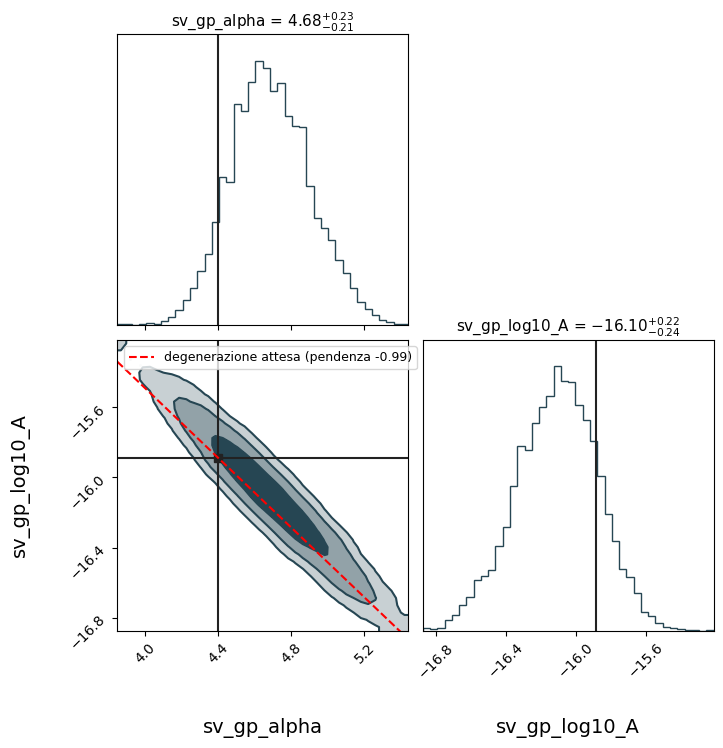

In [21]:
f_toa = np.asarray(sim_sv44_psr.freqs)
w = (1400.0 / f_toa)**(2 * 4.4) / np.asarray(sim_sv44_psr.toaerrs)**2
slope = -np.sum(w * np.log10(1400.0 / f_toa)) / np.sum(w)
nu_eff = 1400.0 / 10**(-slope)
print(f'nu_eff ~ {nu_eff:.0f} MHz, pendenza attesa d(log10_A)/d(alpha) = {slope:.2f}')

a_s  = chain_sim_sv44_af[:, idx_af['J1640+2224_sv_gp_alpha']]
lA_s = chain_sim_sv44_af[:, idx_af['J1640+2224_sv_gp_log10_A']]
print('correlazione di Pearson alpha - log10_A =', np.corrcoef(a_s, lA_s)[0, 1])

fig = corner.corner(
    np.column_stack([a_s, lA_s]),
    labels=['sv_gp_alpha', 'sv_gp_log10_A'],
    truths=[4.4, truths_dict_af['J1640+2224_sv_gp_log10_A']],
    truth_color='#222222',
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.68, 0.95, 0.997),
    smooth=1.0,
    bins=40,
    color='#264653',
)
ax = fig.axes[2]   # pannello 2D in basso a sinistra
xx = np.linspace(a_s.min(), a_s.max(), 100)
ax.plot(xx, truths_dict_af['J1640+2224_sv_gp_log10_A'] + slope * (xx - 4.4), 'r--', lw=1.5,
        label=f'degenerazione attesa (pendenza {slope:.2f})')
ax.legend(fontsize=9)
fig.set_size_inches(8, 8)
fig.savefig('corner_sim_sv44_alphafree_degenerazione.png', dpi=150, bbox_inches='tight')

### Confronto sui 6 parametri comuni: α fisso a 4.0 (notebook 07) vs α libero

Le colonne della catena con α libero sono riordinate per nome secondo `logL.params`, così i pannelli corrispondono.

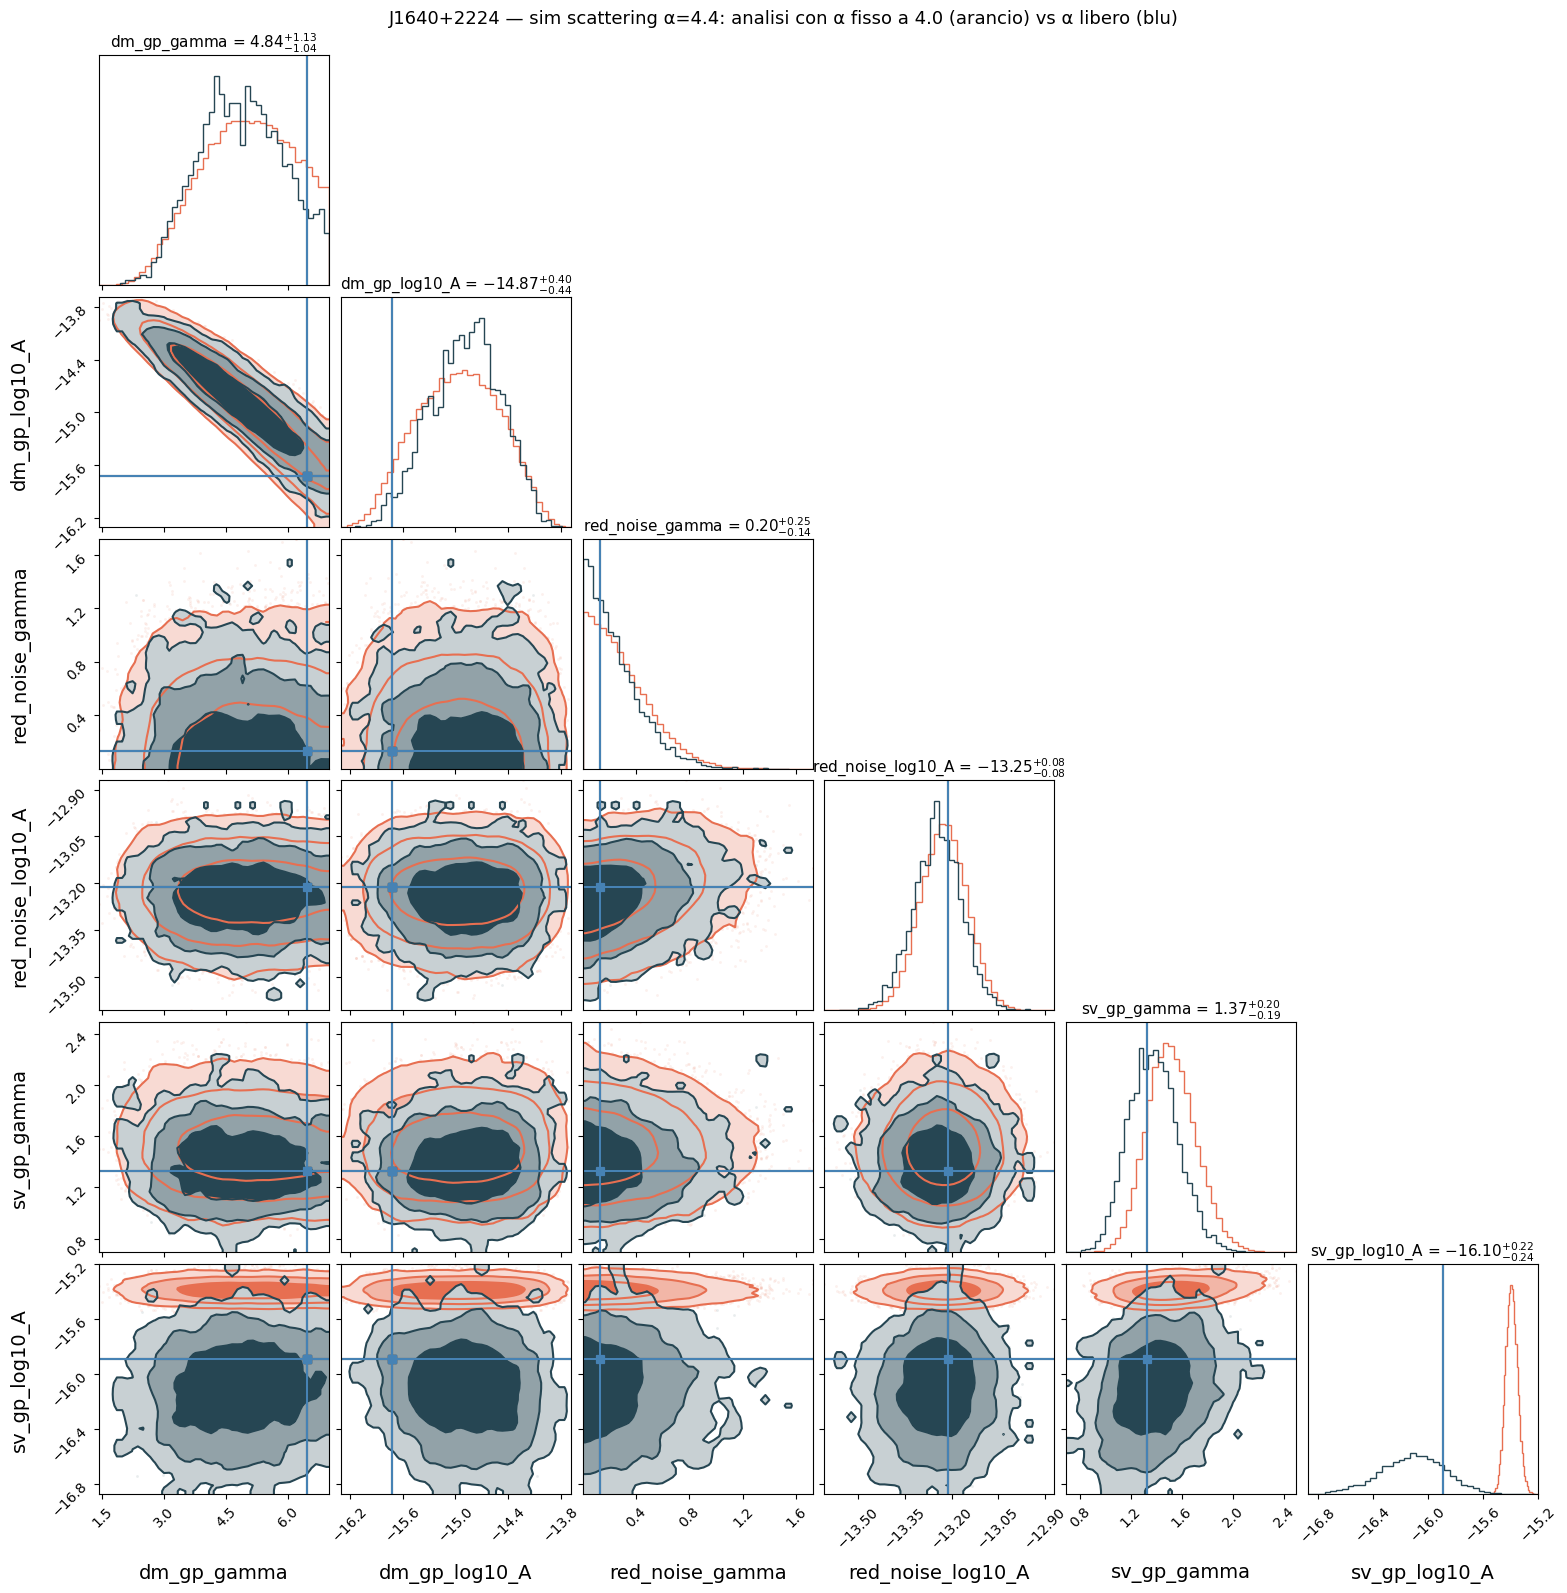

In [22]:
import corner

# colonne della catena alpha-libero riordinate come logL.params (6 parametri, alpha escluso)
chain_af_6 = chain_sim_sv44_af[:, [idx_af[name] for name in logL.params]]

truth_values = [truths_dict_af[p] for p in logL.params]
clean_labels = [name.replace('J1640+2224_', '') for name in logL.params]

# alpha fisso a 4.0 (modello errato) — arancio scuro
fig = corner.corner(
    chain_sim_sv44,
    labels=clean_labels,
    truths=truth_values,
    truth_color='#222222',
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.68, 0.95, 0.997),
    smooth=1.0,
    bins=40,
    color='#E76F51',
)

# alpha libero — blu petrolio
corner.corner(
    chain_af_6,
    labels=clean_labels,
    truths=truth_values,
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.68, 0.95, 0.997),
    smooth=1.0,
    bins=40,
    color='#264653',
    fig=fig
)

fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — sim scattering α=4.4: analisi con α fisso a 4.0 (arancio) vs α libero (blu)', fontsize=13, y=1.00)
fig.savefig('corner_sim_sv44_fixed_vs_alphafree.png', dpi=150, bbox_inches='tight')

inietta qua gwb con gamma 13/3 e -14